# Phân tích ảnh hưởng của các yếu tố đến doanh thu bán lẻ theo ngày theo nhóm sản phẩm

**Phạm vi dữ liệu:** notebook này chỉ đọc file CSV `data/m5-forecasting-accuracy/processed/m5_store_dept_daily_with_weather.csv`.

**Cách làm:** mỗi cụm phân tích có câu hỏi, lý do, code, output thật, sau đó mới rút nhận xét và quyết định bước tiếp theo. Target dự kiến là `daily_revenue`; đơn vị phân tích sẽ được xác nhận từ dữ liệu trước khi modeling.

## 1. Đọc hiểu cấu trúc dữ liệu

**Câu hỏi đang kiểm tra:** Dataset có kích thước bao nhiêu, mỗi dòng đại diện cho điều gì, có đủ cột thời gian/nhóm sản phẩm/doanh thu/cửa hàng/thời tiết không?

**Vì sao quan trọng:** Nếu đơn vị phân tích hoặc target sai, toàn bộ EDA và forecast sẽ bị lệch hướng. Với bài toán forecasting, ta cũng cần xác nhận dữ liệu có trục thời gian đủ dài và phải split theo thời gian.

In [3]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', context='notebook')

DATA_PATH = Path('../data/m5-forecasting-accuracy/processed/m5_store_dept_daily_with_weather.csv')
df = pd.read_csv(DATA_PATH, parse_dates=['date'], low_memory=False)
df = df.sort_values(['date', 'store_id', 'dept_id']).reset_index(drop=True)

summary = pd.DataFrame({
    'metric': [
        'rows', 'columns', 'date_min', 'date_max', 'n_days',
        'n_stores', 'n_states', 'n_categories', 'n_departments',
        'expected complete date-store-dept grid', 'duplicated date-store-dept rows'
    ],
    'value': [
        len(df), df.shape[1], df['date'].min().date(), df['date'].max().date(), df['date'].nunique(),
        df['store_id'].nunique(), df['state_id'].nunique(), df['cat_id'].nunique(), df['dept_id'].nunique(),
        df['date'].nunique() * df['store_id'].nunique() * df['dept_id'].nunique(),
        df.duplicated(['date', 'store_id', 'dept_id']).sum()
    ]
})

display(summary)
print('Columns:')
print(', '.join(df.columns))
display(df.head())

,metric,value
0,rows,135870
1,columns,56
2,date_min,2011-01-29
3,date_max,2016-05-22
4,n_days,1941
5,n_stores,10
6,n_states,3
7,n_categories,3
8,n_departments,7
9,expected complete date-store-dept grid,135870


Columns:
date, d, wm_yr_wk, store_id, state_id, cat_id, dept_id, daily_revenue, daily_units, item_count, active_item_count, weighted_avg_sell_price, has_sales, weekday, wday, month, year, quarter, week_of_year, day_of_month, day_of_year, day_of_week, day_of_week_num, is_weekend, year_month, event_name_1, event_type_1, event_name_2, event_type_2, event_count, snap_CA, snap_TX, snap_WI, snap_active, weather_location_id, location_name, weather_spatial_level, weather_code, temperature_max_c, temperature_min_c, temperature_mean_c, apparent_temperature_mean_c, precipitation_mm, rain_mm, snowfall_cm, wind_speed_max_kmh, wind_gusts_max_kmh, shortwave_radiation_mj_m2, latitude_requested, longitude_requested, latitude_open_meteo, longitude_open_meteo, elevation_m, timezone, utc_offset_seconds, weather_source


,date,d,wm_yr_wk,store_id,state_id,cat_id,dept_id,daily_revenue,daily_units,item_count,active_item_count,weighted_avg_sell_price,has_sales,weekday,wday,month,year,quarter,week_of_year,day_of_month,day_of_year,day_of_week,day_of_week_num,is_weekend,year_month,event_name_1,event_type_1,event_name_2,event_type_2,event_count,snap_CA,snap_TX,snap_WI,snap_active,weather_location_id,location_name,weather_spatial_level,weather_code,temperature_max_c,temperature_min_c,temperature_mean_c,apparent_temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh,wind_gusts_max_kmh,shortwave_radiation_mj_m2,latitude_requested,longitude_requested,latitude_open_meteo,longitude_open_meteo,elevation_m,timezone,utc_offset_seconds,weather_source
0,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_1,681.18,297,216,70,2.293535,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1,6.1,11.7,9.7,0.0,0.0,0.0,10.9,25.9,14.81,34.0522,-118.2437,34.059753,-118.2375,91.0,America/Los_Angeles,-25200,open_meteo_archive
1,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_2,2236.01,674,398,154,3.317522,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1,6.1,11.7,9.7,0.0,0.0,0.0,10.9,25.9,14.81,34.0522,-118.2437,34.059753,-118.2375,91.0,America/Los_Angeles,-25200,open_meteo_archive
2,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_3,4323.46,2268,823,285,1.906287,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1,6.1,11.7,9.7,0.0,0.0,0.0,10.9,25.9,14.81,34.0522,-118.2437,34.059753,-118.2375,91.0,America/Los_Angeles,-25200,open_meteo_archive
3,2011-01-29,d_1,11101,CA_1,CA,HOBBIES,HOBBIES_1,1276.86,528,416,101,2.418295,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1,6.1,11.7,9.7,0.0,0.0,0.0,10.9,25.9,14.81,34.0522,-118.2437,34.059753,-118.2375,91.0,America/Los_Angeles,-25200,open_meteo_archive
4,2011-01-29,d_1,11101,CA_1,CA,HOBBIES,HOBBIES_2,93.05,28,149,17,3.323214,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1,6.1,11.7,9.7,0.0,0.0,0.0,10.9,25.9,14.81,34.0522,-118.2437,34.059753,-118.2375,91.0,America/Los_Angeles,-25200,open_meteo_archive


**Đọc output thật:** Dataset có 135,870 dòng và 56 cột, bao phủ 1,941 ngày từ 2011-01-29 đến 2016-05-22. Số dòng đúng bằng `date × store_id × dept_id = 1,941 × 10 × 7`, và không có dòng trùng theo `date-store-dept`.

**Kết luận cấu trúc:** Mỗi dòng là một quan sát **ngày × cửa hàng × nhóm sản phẩm (`dept_id`)**. Target tự nhiên là `daily_revenue`. Vì có chuỗi thời gian dài theo ngày, bài toán phù hợp là retail analytics kết hợp forecasting/regression theo thời gian, không dùng random split.

**Câu hỏi tiếp theo:** Target và các biến liên quan có sạch không? Có biến nào nhìn giống feature nhưng thật ra là leakage từ target không?

**Quyết định:** Kiểm tra missing, duplicate, phân phối target, và quan hệ giữa `daily_revenue`, `daily_units`, `weighted_avg_sell_price`, `has_sales` trước khi dùng bất kỳ biến nào cho model.

## 2. Chất lượng dữ liệu và rủi ro leakage

**Câu hỏi đang kiểm tra:** Missing data nằm ở đâu? `daily_units`, `has_sales`, `weighted_avg_sell_price` có thể dùng làm feature hay có nguy cơ rò rỉ target?

**Vì sao quan trọng:** Trong retail forecasting, các biến được tạo sau khi biết doanh số ngày đó không được dùng để dự báo ngày đó. Nếu dùng nhầm, model sẽ có metric đẹp nhưng không dùng được trong thực tế.

In [4]:
missing = (
    df.isna().sum()
      .to_frame('missing')
      .assign(pct=lambda x: x['missing'] / len(df))
      .query('missing > 0')
      .sort_values('missing', ascending=False)
)

target_desc = df['daily_revenue'].describe(percentiles=[.01, .05, .25, .50, .75, .90, .95, .99]).to_frame('daily_revenue')
calc_revenue = df['daily_units'] * df['weighted_avg_sell_price']
revenue_diff = (df['daily_revenue'] - calc_revenue).abs()

quality_checks = pd.DataFrame({
    'check': [
        'negative daily_revenue rows',
        'zero daily_revenue pct',
        'non-null price rows',
        'max abs(daily_revenue - daily_units * weighted_avg_sell_price)',
        'pct rows diff < 1 cent when price exists',
        'all missing weighted price rows have zero revenue'
    ],
    'value': [
        int((df['daily_revenue'] < 0).sum()),
        (df['daily_revenue'] == 0).mean(),
        int(calc_revenue.notna().sum()),
        revenue_diff.max(),
        (revenue_diff.dropna() < 0.01).mean(),
        bool((df.loc[df['weighted_avg_sell_price'].isna(), 'daily_revenue'] == 0).all())
    ]
})

print('Missing columns:')
display(missing)
print('\nTarget distribution:')
display(target_desc)
print('\nQuality and leakage checks:')
display(quality_checks)
print('\nRows with missing weighted_avg_sell_price:')
display(df.loc[df['weighted_avg_sell_price'].isna(), ['daily_revenue', 'daily_units', 'has_sales']].describe())
print('\nCorrelation among target-adjacent numeric variables:')
display(df[['daily_revenue', 'daily_units', 'weighted_avg_sell_price', 'active_item_count', 'item_count']].corr().round(3))

Missing columns:


,missing,pct
event_name_2,135590,0.997939
event_type_2,135590,0.997939
event_name_1,124810,0.918599
event_type_1,124810,0.918599
weighted_avg_sell_price,363,0.002672



Target distribution:


,daily_revenue
count,135870.000000
mean,1410.006227
std,1384.234330
min,0.000000
1%,15.379999
5%,42.634500
25%,500.710000
50%,985.790000
75%,1900.507500
90%,3264.716000



Quality and leakage checks:


,check,value
0,negative daily_revenue rows,0
1,zero daily_revenue pct,0.002672
2,non-null price rows,135507
3,max abs(daily_revenue - daily_units * weighted...,0.000469
4,pct rows diff < 1 cent when price exists,1.0
5,all missing weighted price rows have zero revenue,True



Rows with missing weighted_avg_sell_price:


,daily_revenue,daily_units,has_sales
count,363.0,363.0,363.0
mean,0.0,0.0,0.0
std,0.0,0.0,0.0
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0
max,0.0,0.0,0.0



Correlation among target-adjacent numeric variables:


,daily_revenue,daily_units,weighted_avg_sell_price,active_item_count,item_count
daily_revenue,1.000,0.955,-0.125,0.930,0.738
daily_units,0.955,1.000,-0.314,0.901,0.735
weighted_avg_sell_price,-0.125,-0.314,1.000,-0.129,0.100
active_item_count,0.930,0.901,-0.129,1.000,0.833
item_count,0.738,0.735,0.100,0.833,1.000


**Đọc output thật:** Missing chủ yếu nằm ở event thứ hai và event thứ nhất, đây là missing có nghĩa: phần lớn ngày không có event. `weighted_avg_sell_price` thiếu 363 dòng, và tất cả các dòng đó có doanh thu/units bằng 0. Target không âm, nhưng lệch phải rõ: median khoảng 985.79, p99 khoảng 6,484.88, max khoảng 11,198.95.

Điểm quan trọng nhất: `daily_revenue ≈ daily_units × weighted_avg_sell_price` với sai số dưới 1 cent cho toàn bộ dòng có giá. Vì vậy `daily_units` là leakage trực tiếp nếu mục tiêu là dự báo doanh thu. `has_sales` cũng là biến hậu nghiệm vì biết ngày đó có bán hay không. `weighted_avg_sell_price` không trực tiếp là target, nhưng là giá bình quân có trọng số theo mix bán thực tế; nếu mix bán tương lai chưa biết, biến này có rủi ro leakage/availability.

**Câu hỏi tiếp theo:** Doanh thu cao đến từ đâu: nhiều dòng hơn, dept lớn hơn thật sự, cửa hàng lớn hơn, hay do units/assortment?

**Quyết định:** Phân tích phân phối target và đóng góp theo `dept_id`, sau đó kiểm tra store/state concentration.

## 3. Target distribution và đóng góp theo `dept_id`

**Câu hỏi đang kiểm tra:** Doanh thu bị lệch phải vì một vài nhóm sản phẩm/cửa hàng rất lớn hay vì outlier lẻ? Các `dept_id` có số dòng bằng nhau không?

**Vì sao quan trọng:** Nếu một dept chiếm tỷ trọng lớn, insight/model cần đánh giá riêng theo dept. Nếu doanh thu cao chỉ do nhiều quan sát hơn, cách diễn giải sẽ khác với doanh thu trung bình thật sự cao.

,rows,total_revenue,avg_revenue,median_revenue,avg_units,avg_price,avg_active_items,zero_sales_pct,revenue_share
dept_id,,,,,,,,,
FOODS_3,19410,7.234586e+07,3727.247,3440.680,1696.909,2.201,341.124,0.001,0.378
HOUSEHOLD_1,19410,4.213278e+07,2170.674,1963.520,603.959,3.651,197.495,0.003,0.220
FOODS_2,19410,2.559237e+07,1318.514,1226.625,401.598,3.234,128.242,0.003,0.134
HOBBIES_1,19410,2.212024e+07,1139.631,1025.985,293.612,3.960,111.761,0.003,0.115
HOUSEHOLD_2,19410,1.498310e+07,771.927,653.325,156.684,4.899,99.830,0.003,0.078
FOODS_1,19410,1.320180e+07,680.154,631.045,267.409,2.565,79.951,0.002,0.069
HOBBIES_2,19410,1.201400e+06,61.896,55.765,27.905,2.368,17.346,0.004,0.006


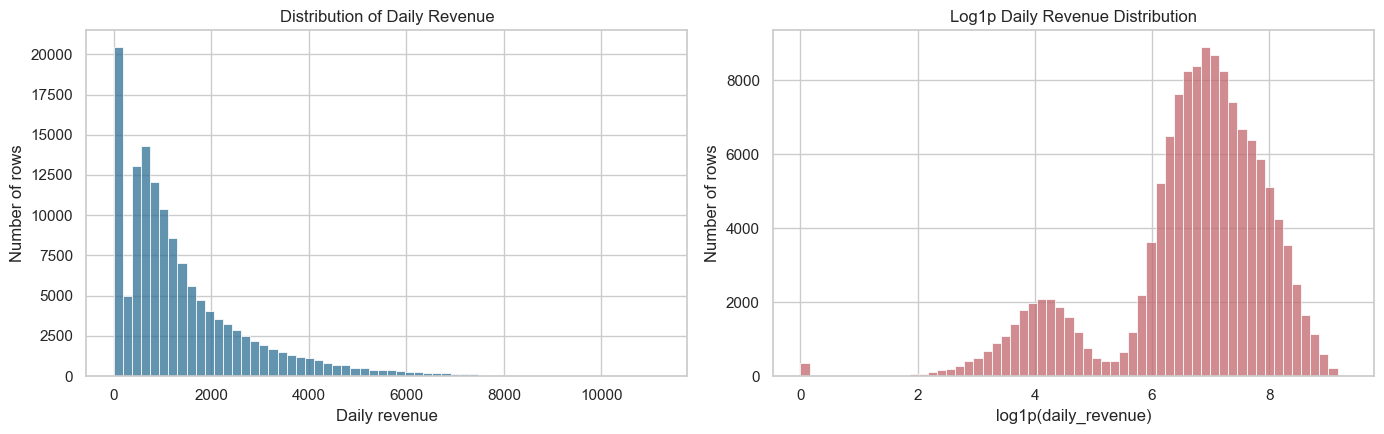

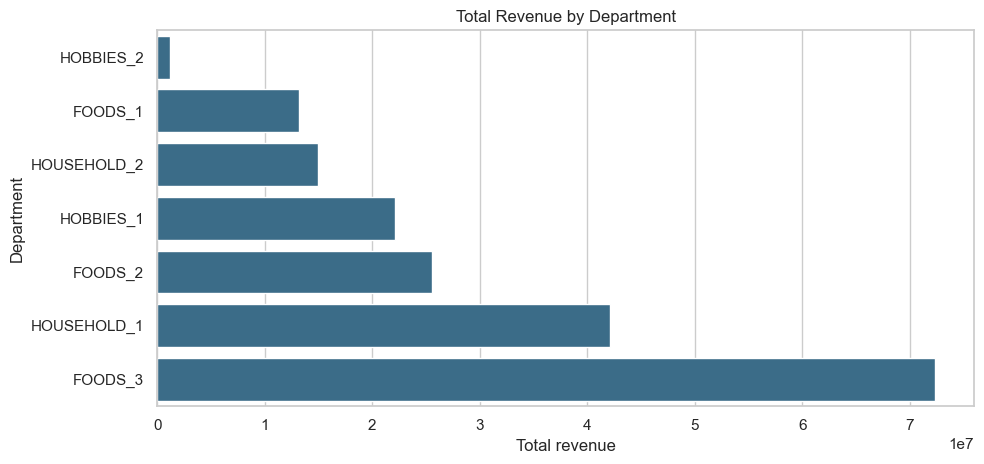

In [5]:
dept_stats = (
    df.groupby('dept_id')
      .agg(
          rows=('daily_revenue', 'size'),
          total_revenue=('daily_revenue', 'sum'),
          avg_revenue=('daily_revenue', 'mean'),
          median_revenue=('daily_revenue', 'median'),
          avg_units=('daily_units', 'mean'),
          avg_price=('weighted_avg_sell_price', 'mean'),
          avg_active_items=('active_item_count', 'mean'),
          zero_sales_pct=('has_sales', lambda s: 1 - s.mean())
      )
      .assign(revenue_share=lambda x: x['total_revenue'] / x['total_revenue'].sum())
      .sort_values('total_revenue', ascending=False)
)

display(dept_stats.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df['daily_revenue'], bins=60, ax=axes[0], color='#2E6F95')
axes[0].set_title('Distribution of Daily Revenue')
axes[0].set_xlabel('Daily revenue')
axes[0].set_ylabel('Number of rows')

sns.histplot(np.log1p(df['daily_revenue']), bins=60, ax=axes[1], color='#C1666B')
axes[1].set_title('Log1p Daily Revenue Distribution')
axes[1].set_xlabel('log1p(daily_revenue)')
axes[1].set_ylabel('Number of rows')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.8))
plot_data = dept_stats.reset_index().sort_values('total_revenue')
sns.barplot(data=plot_data, x='total_revenue', y='dept_id', color='#2E6F95')
plt.title('Total Revenue by Department')
plt.xlabel('Total revenue')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

**Đọc output thật:** Tất cả dept có cùng 19,410 dòng, nên khác biệt doanh thu không đến từ số quan sát. `FOODS_3` chiếm khoảng 37.8% doanh thu toàn bộ, với doanh thu trung bình khoảng 3,727/ngày-cửa hàng-dept. `HOUSEHOLD_1` đứng thứ hai khoảng 22.0%. `HOBBIES_2` chỉ khoảng 0.6% doanh thu, dù số dòng bằng các dept khác.

`FOODS_3` không chỉ có giá cao; thực tế avg price khoảng 2.20, thấp hơn nhiều nhóm khác. Doanh thu cao chủ yếu đến từ units và số active items cao. Đây là tín hiệu business quan trọng: high revenue được dẫn bởi demand volume và assortment breadth hơn là unit price.

**Câu hỏi tiếp theo:** Trong các dept lớn, cửa hàng/state nào đang kéo doanh thu? Có cửa hàng nào chi phối pattern không?

**Quyết định:** Phân tích concentration theo state, store, và cặp store-dept.

## 4. Revenue concentration theo state/store/store-dept

**Câu hỏi đang kiểm tra:** Doanh thu cao tập trung ở bang/cửa hàng nào? Top store-dept có phải chủ yếu là `FOODS_3` không?

**Vì sao quan trọng:** Nếu một số cửa hàng lớn chi phối, mô hình global cần có store/dept identifiers và error analysis phải tách theo group.

State stats:


,rows,total_revenue,avg_revenue,revenue_share
state_id,,,,
CA,54348,8.596736e+07,1581.794,0.449
TX,40761,5.512064e+07,1352.289,0.288
WI,40761,5.048955e+07,1238.673,0.264



Store stats:


total_revenue  avg_revenue  revenue_share
state_id store_id                                           
CA       CA_3       3.269914e+07     2406.649          0.171
         CA_1       2.295428e+07     1689.430          0.120
TX       TX_2       2.089300e+07     1537.720          0.109
         TX_3       1.819030e+07     1338.802          0.095
WI       WI_2       1.813199e+07     1334.510          0.095
CA       CA_2       1.784821e+07     1313.624          0.093
WI       WI_3       1.725013e+07     1269.605          0.090
TX       TX_1       1.603734e+07     1180.345          0.084
WI       WI_1       1.510743e+07     1111.904          0.079
CA       CA_4       1.246573e+07      917.475          0.065


Top store-dept combinations:


,state_id,store_id,dept_id,total_revenue,avg_revenue
16,CA,CA_3,FOODS_3,12441318.39,6409.75
2,CA,CA_1,FOODS_3,9320242.62,4801.77
37,TX,TX_2,FOODS_3,8172091.27,4210.25
19,CA,CA_3,HOUSEHOLD_1,7855048.38,4046.91
65,WI,WI_3,FOODS_3,7319263.64,3770.87
58,WI,WI_2,FOODS_3,6714076.30,3459.08
44,TX,TX_3,FOODS_3,6650708.64,3426.43
30,TX,TX_1,FOODS_3,6112549.87,3149.18
9,CA,CA_2,FOODS_3,5662971.28,2917.55
51,WI,WI_1,FOODS_3,5240284.17,2699.79


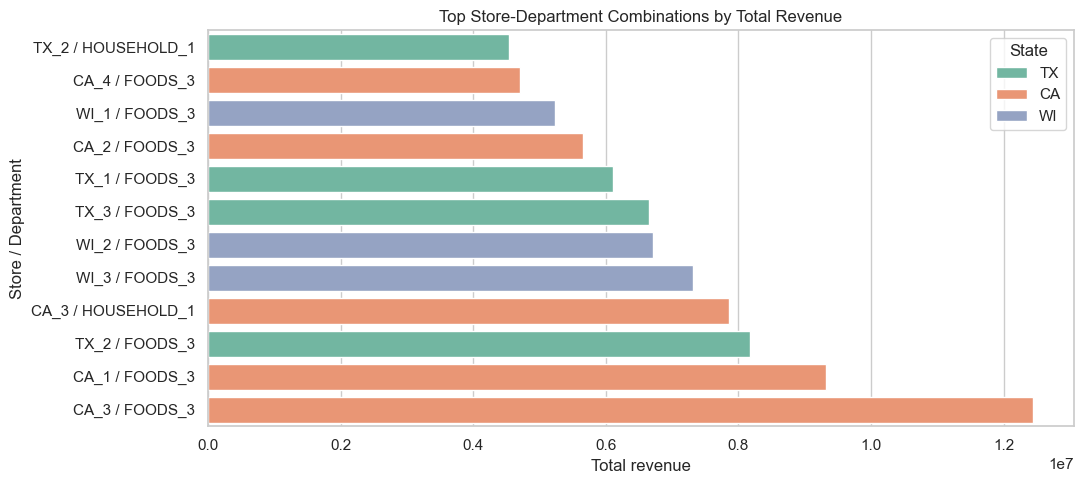

In [6]:
state_stats = (
    df.groupby('state_id')
      .agg(rows=('daily_revenue', 'size'), total_revenue=('daily_revenue', 'sum'), avg_revenue=('daily_revenue', 'mean'))
      .assign(revenue_share=lambda x: x['total_revenue'] / x['total_revenue'].sum())
      .sort_values('total_revenue', ascending=False)
)
store_stats = (
    df.groupby(['state_id', 'store_id'])
      .agg(total_revenue=('daily_revenue', 'sum'), avg_revenue=('daily_revenue', 'mean'))
      .assign(revenue_share=lambda x: x['total_revenue'] / x['total_revenue'].sum())
      .sort_values('total_revenue', ascending=False)
)
top_store_dept = (
    df.groupby(['state_id', 'store_id', 'dept_id'])
      .agg(total_revenue=('daily_revenue', 'sum'), avg_revenue=('daily_revenue', 'mean'))
      .reset_index()
      .sort_values('total_revenue', ascending=False)
      .head(12)
)

print('State stats:')
display(state_stats.round(3))
print('\nStore stats:')
display(store_stats.round(3))
print('\nTop store-dept combinations:')
display(top_store_dept.round(2))

plt.figure(figsize=(11, 5))
plot_data = top_store_dept.assign(store_dept=lambda x: x['store_id'] + ' / ' + x['dept_id']).sort_values('total_revenue')
sns.barplot(data=plot_data, x='total_revenue', y='store_dept', hue='state_id', dodge=False, palette='Set2')
plt.title('Top Store-Department Combinations by Total Revenue')
plt.xlabel('Total revenue')
plt.ylabel('Store / Department')
plt.legend(title='State')
plt.tight_layout()
plt.show()

**Đọc output thật:** CA đóng góp khoảng 44.9% doanh thu; riêng `CA_3` chiếm khoảng 17.1% toàn bộ dataset. Top store-dept gần như bị thống trị bởi `FOODS_3`; `CA_3 / FOODS_3` là tổ hợp lớn nhất, trung bình khoảng 6,410 doanh thu/ngày.

Điều này xác nhận `store_id` và `dept_id` không chỉ là metadata mà là drivers cấu trúc. Nhưng để tìm yếu tố tác động theo ngày, cần chuẩn hóa theo baseline từng store-dept, nếu không các cửa hàng/dept lớn sẽ che mất calendar/event/weather effects.

**Câu hỏi tiếp theo:** Sau khi chuẩn hóa theo median của từng store-dept, calendar effects có còn rõ không?

**Quyết định:** Tạo `revenue_vs_pair_median` chỉ cho EDA, rồi kiểm tra day-of-week, month, year trend.

## 5. Calendar effects sau khi chuẩn hóa theo store-dept baseline

**Câu hỏi đang kiểm tra:** Doanh thu có pattern theo ngày trong tuần/tháng/năm không, và pattern đó có phải chỉ do mix store-dept không?

**Vì sao quan trọng:** Calendar feature là nhóm feature biết trước tại thời điểm dự báo, thường là nền tảng của forecast model.

Day-of-week effect:


,day_of_week_num,day_of_week,avg_revenue,median_revenue,avg_ratio
0,0,Monday,1355.165,942.125,0.992
1,1,Tuesday,1242.378,888.925,0.933
2,2,Wednesday,1227.608,888.065,0.934
3,3,Thursday,1233.031,890.560,0.938
4,4,Friday,1395.248,1010.880,1.053
5,5,Saturday,1703.137,1213.360,1.256
6,6,Sunday,1711.331,1180.240,1.235



Month effect:


,month,avg_revenue,avg_ratio
0,1,1395.150,1.041
1,2,1431.404,1.080
2,3,1425.038,1.066
3,4,1429.865,1.058
4,5,1416.183,1.061
5,6,1387.388,1.010
6,7,1397.195,1.002
7,8,1430.069,1.042
8,9,1424.462,1.036
9,10,1424.263,1.080



Year trend:


,year,rows,total_revenue,avg_revenue,avg_ratio
0,2011,23590,2.389134e+07,1012.774,0.747
1,2012,25620,3.264920e+07,1274.364,0.910
2,2013,25550,3.592337e+07,1406.003,1.016
3,2014,25550,3.786191e+07,1481.875,1.100
4,2015,25550,4.241646e+07,1660.135,1.291
5,2016,10010,1.883527e+07,1881.645,1.452


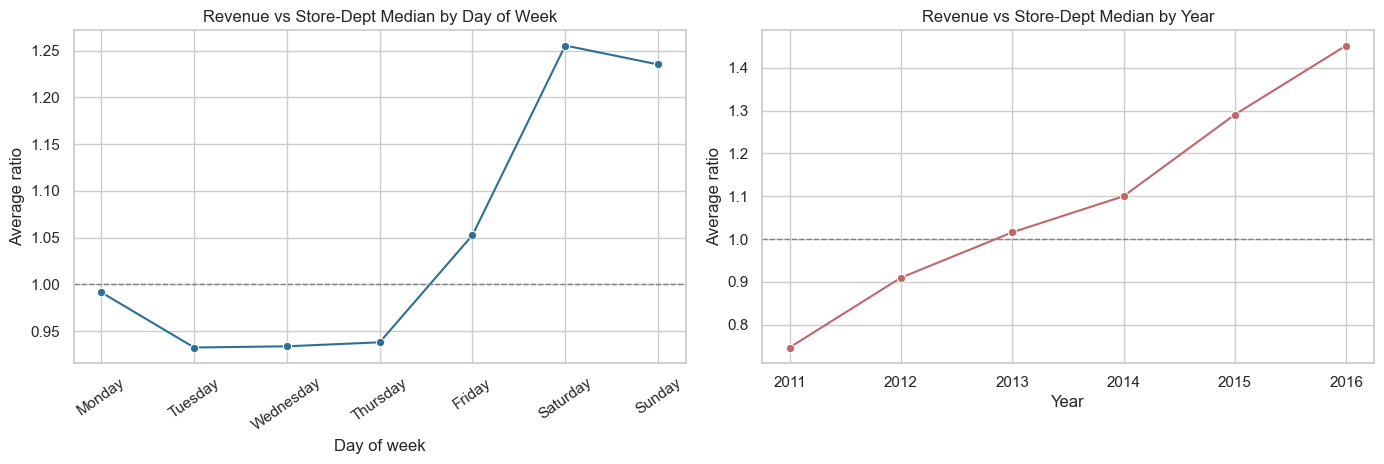

In [7]:
pair_median = df.groupby(['store_id', 'dept_id'])['daily_revenue'].transform('median').replace(0, np.nan)
df_eda = df.assign(revenue_vs_pair_median=df['daily_revenue'] / pair_median)

dow = (
    df_eda.groupby(['day_of_week_num', 'day_of_week'])
          .agg(avg_revenue=('daily_revenue', 'mean'), median_revenue=('daily_revenue', 'median'), avg_ratio=('revenue_vs_pair_median', 'mean'))
          .reset_index()
          .sort_values('day_of_week_num')
)
month = (
    df_eda.groupby('month')
          .agg(avg_revenue=('daily_revenue', 'mean'), avg_ratio=('revenue_vs_pair_median', 'mean'))
          .reset_index()
)
year = (
    df_eda.groupby('year')
          .agg(rows=('daily_revenue', 'size'), total_revenue=('daily_revenue', 'sum'), avg_revenue=('daily_revenue', 'mean'), avg_ratio=('revenue_vs_pair_median', 'mean'))
          .reset_index()
)

print('Day-of-week effect:')
display(dow.round(3))
print('\nMonth effect:')
display(month.round(3))
print('\nYear trend:')
display(year.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.lineplot(data=dow, x='day_of_week', y='avg_ratio', marker='o', ax=axes[0], color='#2E6F95')
axes[0].set_title('Revenue vs Store-Dept Median by Day of Week')
axes[0].set_xlabel('Day of week')
axes[0].set_ylabel('Average ratio')
axes[0].tick_params(axis='x', rotation=35)
axes[0].axhline(1, color='gray', linewidth=1, linestyle='--')

sns.lineplot(data=year, x='year', y='avg_ratio', marker='o', ax=axes[1], color='#C1666B')
axes[1].set_title('Revenue vs Store-Dept Median by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average ratio')
axes[1].axhline(1, color='gray', linewidth=1, linestyle='--')
plt.tight_layout()
plt.show()

**Đọc output thật:** Cuối tuần là pattern mạnh và có ý nghĩa: Saturday/Sunday cao hơn baseline khoảng 23-26%, trong khi Tuesday-Thursday thấp hơn baseline. Year trend tăng rõ từ 2011 đến 2016, cho thấy demand level thay đổi theo thời gian; mô hình cần có trend/time và lag features.

Month effect có dao động nhưng không quá mạnh so với day-of-week/year. Vì vậy month có thể hữu ích, nhưng không nên kỳ vọng nó là driver chính.

**Câu hỏi tiếp theo:** Weekend effect có đồng đều giữa các dept không? Nếu khác nhau, interaction calendar × dept có thể quan trọng.

**Quyết định:** Kiểm tra weekend lift riêng theo `dept_id`.

## 6. Weekend lift theo department

**Câu hỏi đang kiểm tra:** Ảnh hưởng cuối tuần có khác nhau theo nhóm sản phẩm không?

**Vì sao quan trọng:** Cùng một calendar effect có thể tác động rất khác giữa FOODS, HOUSEHOLD và HOBBIES. Nếu lift khác nhau, `dept_id` và calendar features cần được model học chung, hoặc tạo interaction nếu dùng model tuyến tính.

is_weekend,weekday_ratio,weekend_ratio,weekend_lift_pct
dept_id,,,
HOUSEHOLD_1,0.93,1.31,40.44
HOUSEHOLD_2,0.94,1.27,36.20
FOODS_3,0.94,1.25,32.88
FOODS_2,1.00,1.29,29.15
HOBBIES_1,0.97,1.24,28.02
HOBBIES_2,1.03,1.22,18.27
FOODS_1,0.98,1.14,15.65


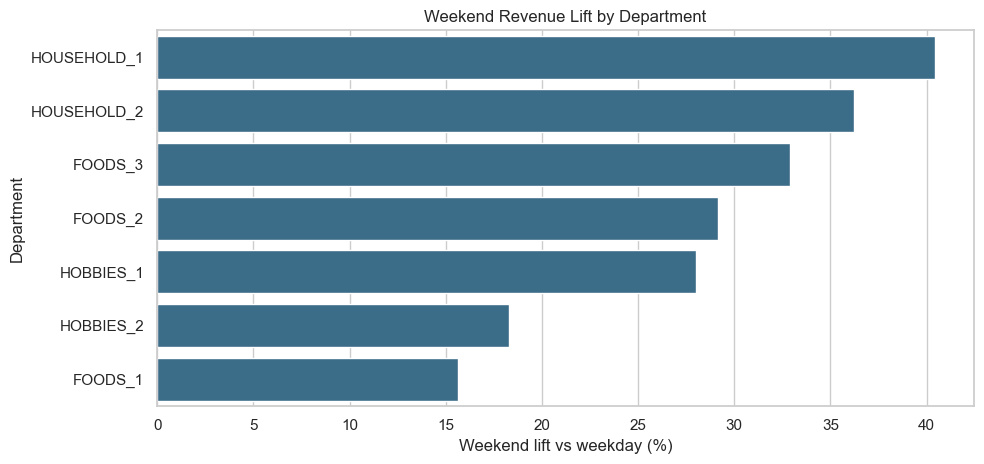

In [8]:
dept_weekend = (
    df_eda.groupby(['dept_id', 'is_weekend'])
          .agg(avg_revenue=('daily_revenue', 'mean'), avg_ratio=('revenue_vs_pair_median', 'mean'))
          .reset_index()
)
weekend_lift = (
    dept_weekend.pivot(index='dept_id', columns='is_weekend', values='avg_ratio')
                .rename(columns={0: 'weekday_ratio', 1: 'weekend_ratio'})
                .assign(weekend_lift_pct=lambda x: (x['weekend_ratio'] / x['weekday_ratio'] - 1) * 100)
                .sort_values('weekend_lift_pct', ascending=False)
)

display(weekend_lift.round(2))

plt.figure(figsize=(10, 4.8))
sns.barplot(data=weekend_lift.reset_index(), x='weekend_lift_pct', y='dept_id', color='#2E6F95')
plt.title('Weekend Revenue Lift by Department')
plt.xlabel('Weekend lift vs weekday (%)')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

**Đọc output thật:** Weekend lift không đồng đều. `HOUSEHOLD_1` và `HOUSEHOLD_2` có lift khoảng 40% và 36%, cao hơn `FOODS_1` chỉ khoảng 16%. `FOODS_3` vẫn lift lớn khoảng 33%, nên nhóm doanh thu lớn nhất cũng nhạy với cuối tuần.

**Insight:** Calendar không tác động chung chung; nó khác theo department. LightGBM có thể tự học interaction giữa `dept_id` và `day_of_week_num`, nên không nhất thiết phải tạo thủ công nếu dùng tree model.

**Câu hỏi tiếp theo:** Event và SNAP có tạo lift thật hay chỉ phản ánh calendar/seasonality?

**Quyết định:** Kiểm tra event theo type/name và SNAP lift theo state-dept trên normalized ratio.

## 7. Event và SNAP: signal chung hay tác động cục bộ?

**Câu hỏi đang kiểm tra:** Event type/name và SNAP có ảnh hưởng đến doanh thu không? Tác động đó có tập trung ở dept/state cụ thể không?

**Vì sao quan trọng:** Event/SNAP là feature biết trước theo lịch, nhưng EDA phải phân biệt signal ổn định với vài ngày đặc biệt như Christmas/Thanksgiving.

Event type effect:


,rows,avg_revenue,avg_ratio
event_type_1,,,
Cultural,2590,1435.364,1.078
No event,124810,1414.878,1.053
Religious,3780,1416.678,1.053
Sporting,1120,1440.027,1.047
National,3570,1204.823,0.862



Lowest event-name ratios:


,event_type_1,event_name_1,rows,avg_revenue,avg_ratio
7,National,Christmas,350,0.433,0.000
15,National,Thanksgiving,350,833.315,0.575
13,National,NewYear,350,1070.807,0.773
9,National,IndependenceDay,350,1309.886,0.889
22,Religious,LentWeek2,420,1219.355,0.933
29,Sporting,NBAFinalsStart,350,1261.989,0.938
28,Sporting,NBAFinalsEnd,350,1337.447,0.968
23,Religious,OrthodoxChristmas,350,1357.127,0.969
12,National,MemorialDay,350,1366.480,0.980
21,Religious,LentStart,420,1263.923,0.981



Highest event-name ratios:


,event_type_1,event_name_1,rows,avg_revenue,avg_ratio
18,Religious,Chanukah End,350,1386.392,1.074
6,Cultural,ValentinesDay,420,1391.238,1.075
0,Cultural,Cinco De Mayo,350,1434.942,1.087
4,Cultural,Mother's day,420,1511.045,1.104
26,Religious,Purim End,420,1492.736,1.107
25,Religious,Pesach End,420,1512.199,1.122
1,Cultural,Easter,350,1641.613,1.181
10,National,LaborDay,350,1683.102,1.183
30,Sporting,SuperBowl,420,1673.875,1.205
24,Religious,OrthodoxEaster,350,1770.730,1.294



Top SNAP lift by state-dept:


,snap_active,snap0,snap1,snap_lift_pct
state_id,dept_id,,,
WI,FOODS_2,0.89,1.34,50.83
TX,FOODS_2,0.93,1.23,32.64
WI,FOODS_3,0.93,1.17,25.88
CA,FOODS_2,1.09,1.27,16.46
TX,FOODS_3,0.98,1.12,14.32
WI,FOODS_1,1.01,1.13,11.58
CA,FOODS_3,1.01,1.09,7.54
TX,FOODS_1,1.00,1.07,6.92
WI,HOUSEHOLD_1,1.03,1.06,3.43


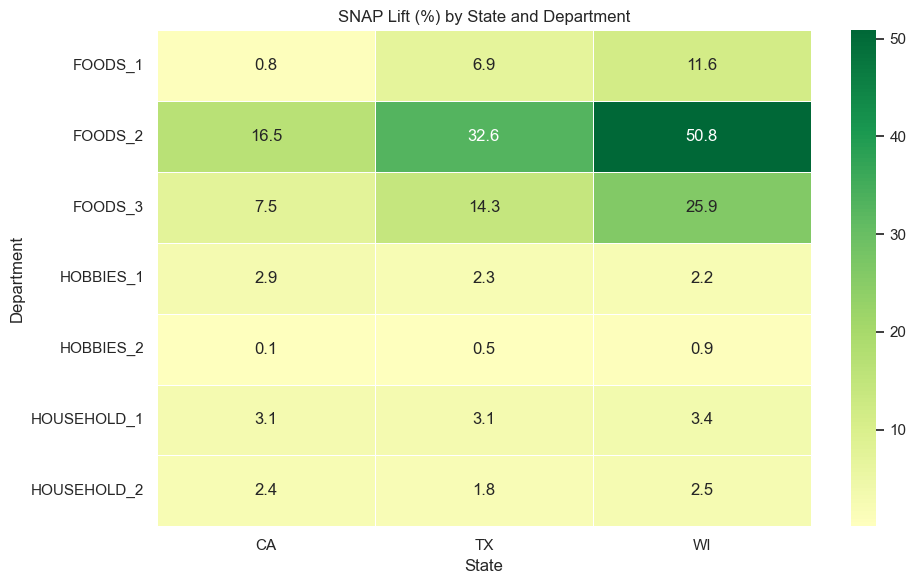

In [9]:
event_type = (
    df_eda.fillna({'event_type_1': 'No event'})
          .groupby('event_type_1')
          .agg(rows=('daily_revenue', 'size'), avg_revenue=('daily_revenue', 'mean'), avg_ratio=('revenue_vs_pair_median', 'mean'))
          .sort_values('avg_ratio', ascending=False)
)

event_name = (
    df_eda.fillna({'event_name_1': 'No event', 'event_type_1': 'No event'})
          .groupby(['event_type_1', 'event_name_1'])
          .agg(rows=('daily_revenue', 'size'), avg_revenue=('daily_revenue', 'mean'), avg_ratio=('revenue_vs_pair_median', 'mean'))
          .reset_index()
          .sort_values('avg_ratio')
)

snap_lift = (
    df_eda.groupby(['state_id', 'dept_id', 'snap_active'])
          .agg(avg_ratio=('revenue_vs_pair_median', 'mean'))
          .reset_index()
          .pivot(index=['state_id', 'dept_id'], columns='snap_active', values='avg_ratio')
          .rename(columns={0: 'snap0', 1: 'snap1'})
          .assign(snap_lift_pct=lambda x: (x['snap1'] / x['snap0'] - 1) * 100)
          .sort_values('snap_lift_pct', ascending=False)
)

print('Event type effect:')
display(event_type.round(3))
print('\nLowest event-name ratios:')
display(event_name.head(10).round(3))
print('\nHighest event-name ratios:')
display(event_name.tail(10).round(3))
print('\nTop SNAP lift by state-dept:')
display(snap_lift.head(15).round(2))

plt.figure(figsize=(10, 6))
heat_data = snap_lift.reset_index().pivot(index='dept_id', columns='state_id', values='snap_lift_pct')
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='RdYlGn', center=0, linewidths=.5)
plt.title('SNAP Lift (%) by State and Department')
plt.xlabel('State')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

**Đọc output thật:** Event type nhìn tổng quát khá nhiễu. National events thấp hơn baseline chủ yếu vì Christmas gần như bằng 0 và Thanksgiving thấp. Ngược lại SuperBowl, Easter/OrthodoxEaster, LaborDay cao hơn baseline. Vì vậy `event_name_1` hữu ích hơn chỉ dùng `event_type_1`, nhưng số ngày mỗi event nhỏ nên dễ overfit.

SNAP lift có pattern business rõ hơn: tác động mạnh nhất nằm ở FOODS, đặc biệt `WI / FOODS_2` khoảng +51%, `TX / FOODS_2` khoảng +33%, `WI / FOODS_3` khoảng +26%. Non-food dept gần như lift nhỏ.

**Insight:** SNAP không phải hiệu ứng toàn dataset; nó là state × dept signal, hợp lý về business vì SNAP liên quan thực phẩm. LightGBM có thể học interaction từ `state_id`, `dept_id`, `snap_active`.

**Câu hỏi tiếp theo:** Weather có tác động ổn định không, hay chỉ là proxy của mùa/thời gian/state?

**Quyết định:** Kiểm tra mưa và nhiệt độ theo state trên normalized ratio, sau đó để ablation quyết định weather có giúp forecast không.

## 8. Weather signal: kiểm tra trước khi đưa vào model

**Câu hỏi đang kiểm tra:** Mưa/nhiệt độ có quan hệ rõ với doanh thu sau khi chuẩn hóa store-dept không? Tác động có khác theo state không?

**Vì sao quan trọng:** Weather có thể ảnh hưởng traffic và demand, nhưng cũng rất dễ bị confound với seasonality. Nếu EDA thấy signal yếu, ablation phải là trọng tài.

Rain effect:


,rain_group,rows,avg_revenue,avg_ratio
0,no_rain,94619,1438.546,1.048
1,light_rain_0_5mm,28525,1354.243,1.052
2,heavy_rain_ge_5mm,12726,1322.799,1.047



Temperature quintiles by state:


,state_id,temp_bin,avg_ratio,temp_min,temp_max
0,CA,Q1 cold,1.011,4.8,13.6
1,CA,Q2,1.042,13.6,16.5
2,CA,Q3,1.082,16.5,19.9
3,CA,Q4,1.074,19.9,23.3
4,CA,Q5 hot,1.085,23.3,31.8
5,TX,Q1 cold,1.034,-7.3,10.8
6,TX,Q2,1.078,10.8,17.4
7,TX,Q3,1.082,17.4,22.7
8,TX,Q4,1.038,22.7,28.4
9,TX,Q5 hot,0.993,28.4,37.2


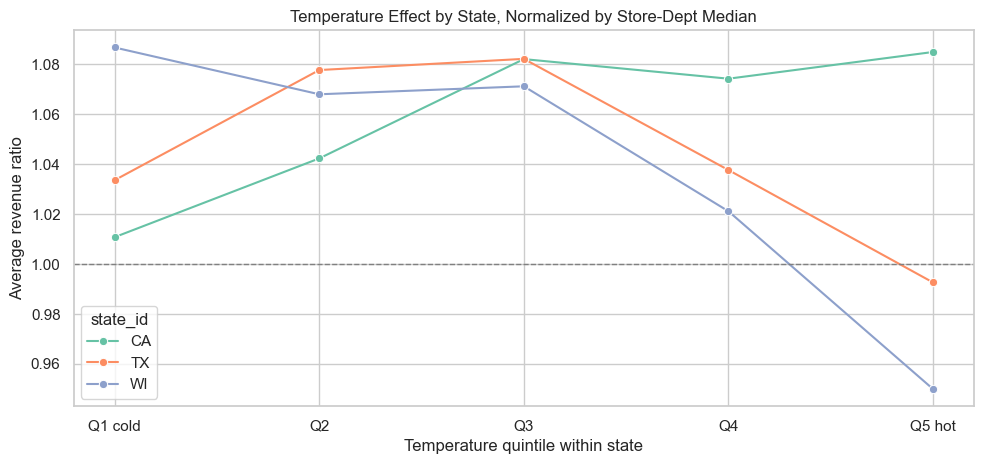

In [10]:
weather_rows = []
for label, mask in [
    ('no_rain', df_eda['precipitation_mm'].fillna(0) == 0),
    ('light_rain_0_5mm', (df_eda['precipitation_mm'].fillna(0) > 0) & (df_eda['precipitation_mm'].fillna(0) < 5)),
    ('heavy_rain_ge_5mm', df_eda['precipitation_mm'].fillna(0) >= 5),
]:
    sub = df_eda[mask]
    weather_rows.append({
        'rain_group': label,
        'rows': len(sub),
        'avg_revenue': sub['daily_revenue'].mean(),
        'avg_ratio': sub['revenue_vs_pair_median'].mean()
    })
rain_effect = pd.DataFrame(weather_rows)

temp_rows = []
for state_id, sub in df_eda.groupby('state_id'):
    bins = pd.qcut(sub['temperature_mean_c'].rank(method='first'), 5, labels=['Q1 cold', 'Q2', 'Q3', 'Q4', 'Q5 hot'])
    tab = (
        sub.assign(temp_bin=bins)
           .groupby('temp_bin', observed=False)
           .agg(avg_ratio=('revenue_vs_pair_median', 'mean'), temp_min=('temperature_mean_c', 'min'), temp_max=('temperature_mean_c', 'max'))
           .reset_index()
    )
    tab.insert(0, 'state_id', state_id)
    temp_rows.append(tab)
temp_by_state = pd.concat(temp_rows, ignore_index=True)

print('Rain effect:')
display(rain_effect.round(3))
print('\nTemperature quintiles by state:')
display(temp_by_state.round(3))

plt.figure(figsize=(10, 4.8))
sns.lineplot(data=temp_by_state, x='temp_bin', y='avg_ratio', hue='state_id', marker='o', palette='Set2')
plt.title('Temperature Effect by State, Normalized by Store-Dept Median')
plt.xlabel('Temperature quintile within state')
plt.ylabel('Average revenue ratio')
plt.axhline(1, color='gray', linewidth=1, linestyle='--')
plt.tight_layout()
plt.show()

**Đọc output thật:** Rain groups có ratio gần nhau, nên mưa không tạo signal đơn giản. Nhiệt độ có quan hệ phi tuyến và khác theo state: CA tăng nhẹ khi nóng hơn, trong khi TX/WI giảm ở quintile nóng nhất. Nhưng đây có thể là seasonality hoặc shopping pattern mùa hè, không chắc là weather causal.

**Insight:** Weather là candidate feature hợp lý nhưng rủi ro nhiễu/confounding cao. Nếu ablation không cải thiện validation, không nên kết luận weather là driver forecast mạnh.

**Câu hỏi tiếp theo:** Những feature nào hợp lệ cho forecasting, feature nào chỉ dùng EDA, feature nào có nguy cơ leakage?

**Quyết định:** Lập bảng feature engineering/leakage trước khi train model.

## 9. Feature engineering plan và leakage review

**Câu hỏi đang kiểm tra:** Feature nào đến từ insight nào, có biết trước lúc dự báo không, và sẽ kiểm thử ra sao?

**Vì sao quan trọng:** Không tạo feature tùy tiện. Mỗi nhóm feature phải có nguồn insight và ablation test.

In [11]:
feature_plan = pd.DataFrame([
    {
        'feature_group': 'calendar identifiers',
        'source_insight': 'Weekend and year trend are strong; calendar is known ahead.',
        'examples': 'day_of_week_num, is_weekend, month, week_of_year, days_since_start',
        'leakage_risk': 'Low',
        'available_at_prediction_time': 'Yes',
        'test_method': 'Baseline model',
        'decision_rule': 'Keep as minimum forecast baseline'
    },
    {
        'feature_group': 'store/dept/category identifiers',
        'source_insight': 'Revenue level differs structurally by store and dept.',
        'examples': 'store_id, state_id, cat_id, dept_id',
        'leakage_risk': 'Low',
        'available_at_prediction_time': 'Yes',
        'test_method': 'Included in baseline',
        'decision_rule': 'Keep'
    },
    {
        'feature_group': 'event and SNAP',
        'source_insight': 'SNAP lift is concentrated in FOODS and some states; event names have special spikes/dips.',
        'examples': 'event_count, event_type_1, event_name_1, snap_active',
        'leakage_risk': 'Low',
        'available_at_prediction_time': 'Yes from calendar',
        'test_method': 'Ablation: baseline vs +event_snap',
        'decision_rule': 'Keep only if validation improves or business interpretability needed'
    },
    {
        'feature_group': 'weather',
        'source_insight': 'Temperature has state-specific nonlinear signal, rain is weak.',
        'examples': 'temperature_mean_c, precipitation_mm, wind, radiation, rain flags',
        'leakage_risk': 'Medium availability risk',
        'available_at_prediction_time': 'Only if weather forecast/scenario is available',
        'test_method': 'Ablation: +event_snap vs +weather',
        'decision_rule': 'Keep if validation improves; otherwise treat as exploratory'
    },
    {
        'feature_group': 'past revenue lags/rolling',
        'source_insight': 'Year trend and store-dept demand persistence are strong.',
        'examples': 'revenue_lag_7, lag_28, rolling mean/std/median shifted before current day',
        'leakage_risk': 'Low for rolling one-step-ahead; higher for fixed long horizon if not recursive',
        'available_at_prediction_time': 'Yes for observed past sales',
        'test_method': 'Ablation: +weather vs +lags',
        'decision_rule': 'Keep if validation improves'
    },
    {
        'feature_group': 'price/availability',
        'source_insight': 'Revenue is highly related to active items and weighted price.',
        'examples': 'weighted_avg_sell_price, item_count, active_item_count',
        'leakage_risk': 'Medium/High',
        'available_at_prediction_time': 'Only if planned assortment and non-target-derived price are known',
        'test_method': 'Separate risky/upper-bound ablation',
        'decision_rule': 'Do not use as default operational model unless data lineage is confirmed'
    },
    {
        'feature_group': 'target-adjacent leakage variables',
        'source_insight': 'daily_revenue equals daily_units times weighted price; has_sales knows outcome.',
        'examples': 'daily_units, has_sales',
        'leakage_risk': 'High',
        'available_at_prediction_time': 'No',
        'test_method': 'Excluded from modeling',
        'decision_rule': 'Drop from input features'
    }
])

display(feature_plan)

,feature_group,source_insight,examples,leakage_risk,available_at_prediction_time,test_method,decision_rule
0,calendar identifiers,Weekend and year trend are strong; calendar is...,"day_of_week_num, is_weekend, month, week_of_ye...",Low,Yes,Baseline model,Keep as minimum forecast baseline
1,store/dept/category identifiers,Revenue level differs structurally by store an...,"store_id, state_id, cat_id, dept_id",Low,Yes,Included in baseline,Keep
2,event and SNAP,SNAP lift is concentrated in FOODS and some st...,"event_count, event_type_1, event_name_1, snap_...",Low,Yes from calendar,Ablation: baseline vs +event_snap,Keep only if validation improves or business i...
3,weather,Temperature has state-specific nonlinear signa...,"temperature_mean_c, precipitation_mm, wind, ra...",Medium availability risk,Only if weather forecast/scenario is available,Ablation: +event_snap vs +weather,Keep if validation improves; otherwise treat a...
4,past revenue lags/rolling,Year trend and store-dept demand persistence a...,"revenue_lag_7, lag_28, rolling mean/std/median...",Low for rolling one-step-ahead; higher for fix...,Yes for observed past sales,Ablation: +weather vs +lags,Keep if validation improves
5,price/availability,Revenue is highly related to active items and ...,"weighted_avg_sell_price, item_count, active_it...",Medium/High,Only if planned assortment and non-target-deri...,Separate risky/upper-bound ablation,Do not use as default operational model unless...
6,target-adjacent leakage variables,daily_revenue equals daily_units times weighte...,"daily_units, has_sales",High,No,Excluded from modeling,Drop from input features


**Đọc output thật:** Feature plan tách rõ ba lớp: feature sạch biết trước, exogenous feature cần điều kiện availability, và feature có nguy cơ leakage. `daily_units`/`has_sales` bị loại. `weighted_avg_sell_price`/`active_item_count` chỉ được đưa vào một ablation riêng như kịch bản rủi ro/upper-bound.

**Câu hỏi tiếp theo:** Với split thời gian đúng, nhóm feature nào thật sự giúp forecast?

**Quyết định:** Tạo lag/rolling shifted, split train/validation/test theo 56 ngày cuối, rồi chạy LightGBM ablation.

## 10. Time split và feature engineering cho forecasting

**Câu hỏi đang kiểm tra:** Split theo thời gian thế nào và lag/rolling có được tạo chỉ từ quá khứ không?

**Vì sao quan trọng:** Forecasting không được random split. Rolling feature phải `shift` trước khi tính để không nhìn thấy doanh thu ngày hiện tại.

In [12]:
df_model = df.sort_values(['store_id', 'dept_id', 'date']).reset_index(drop=True).copy()
keys = ['store_id', 'dept_id']
g = df_model.groupby(keys, sort=False)['daily_revenue']

for lag in [7, 14, 28, 56]:
    df_model[f'revenue_lag_{lag}'] = g.shift(lag)

shifted_revenue = g.shift(1)
for win in [7, 28, 56]:
    df_model[f'revenue_roll_mean_{win}'] = (
        shifted_revenue.groupby([df_model['store_id'], df_model['dept_id']])
        .rolling(win).mean().reset_index(level=[0, 1], drop=True)
    )
    df_model[f'revenue_roll_std_{win}'] = (
        shifted_revenue.groupby([df_model['store_id'], df_model['dept_id']])
        .rolling(win).std().reset_index(level=[0, 1], drop=True)
    )

for win in [7, 28]:
    df_model[f'revenue_roll_median_{win}'] = (
        shifted_revenue.groupby([df_model['store_id'], df_model['dept_id']])
        .rolling(win).median().reset_index(level=[0, 1], drop=True)
    )

first_date = df_model['date'].min()
df_model['days_since_start'] = (df_model['date'] - first_date).dt.days
df_model['rain_flag'] = (df_model['precipitation_mm'].fillna(0) > 0).astype(int)
df_model['heavy_rain_flag'] = (df_model['precipitation_mm'].fillna(0) >= 5).astype(int)
df_model['temp_mean_sq'] = df_model['temperature_mean_c'] ** 2

max_date = df_model['date'].max()
test_start = max_date - pd.Timedelta(days=55)
val_start = test_start - pd.Timedelta(days=56)

train = df_model[df_model['date'] < val_start].copy()
val = df_model[(df_model['date'] >= val_start) & (df_model['date'] < test_start)].copy()
test = df_model[df_model['date'] >= test_start].copy()

split_summary = pd.DataFrame([
    {'split': 'train', 'start': train['date'].min().date(), 'end': train['date'].max().date(), 'rows': len(train)},
    {'split': 'validation', 'start': val['date'].min().date(), 'end': val['date'].max().date(), 'rows': len(val)},
    {'split': 'test', 'start': test['date'].min().date(), 'end': test['date'].max().date(), 'rows': len(test)},
])

lag_cols = [c for c in df_model.columns if c.startswith('revenue_lag_') or c.startswith('revenue_roll_')]
lag_missing = df_model[lag_cols].isna().mean().sort_values(ascending=False).to_frame('missing_pct')

display(split_summary)
print('Lag/rolling feature missing rates caused by early history:')
display(lag_missing.round(3))

,split,start,end,rows
0,train,2011-01-29,2016-01-31,128030
1,validation,2016-02-01,2016-03-27,3920
2,test,2016-03-28,2016-05-22,3920


Lag/rolling feature missing rates caused by early history:


,missing_pct
revenue_lag_56,0.029
revenue_roll_mean_56,0.029
revenue_roll_std_56,0.029
revenue_lag_28,0.014
revenue_roll_mean_28,0.014
revenue_roll_std_28,0.014
revenue_roll_median_28,0.014
revenue_lag_14,0.007
revenue_lag_7,0.004
revenue_roll_mean_7,0.004


**Đọc output thật:** Train kết thúc trước validation; validation là 2016-02-01 đến 2016-03-27, test là 2016-03-28 đến 2016-05-22. Mỗi validation/test có 3,920 dòng, tương ứng 56 ngày × 10 store × 7 dept.

Lag missing chỉ xuất hiện ở giai đoạn đầu lịch sử, đúng kỳ vọng. Các rolling feature được shift trước khi rolling, nên không dùng doanh thu ngày hiện tại. Notebook này đánh giá theo **rolling one-step-ahead setup**: doanh thu quá khứ đã quan sát được có thể dùng. Nếu cần dự báo fixed 56-day horizon không quan sát ngày trung gian, cần recursive simulation hoặc chỉ dùng lag đủ xa.

**Câu hỏi tiếp theo:** Nhóm feature nào cải thiện validation thật sự?

**Quyết định:** Chạy LightGBM ablation: baseline calendar/id → event/SNAP → weather → lag/rolling → log target → risky price/availability.

## 11. LightGBM ablation

**Câu hỏi đang kiểm tra:** Insight từ EDA có thật sự cải thiện forecast trên validation không?

**Vì sao quan trọng:** Không kết luận feature tốt chỉ vì biểu đồ nhìn hợp lý. Validation theo thời gian là bước kiểm chứng.

,experiment,n_features,log_target,val_MAE,val_RMSE,val_R2,val_WAPE,test_MAE,test_RMSE,test_R2,test_WAPE
0,baseline_calendar_id,13,False,203.7507,330.4028,0.9587,0.1084,232.2500,378.2146,0.9507,0.1190
1,+event_snap,17,False,207.3343,337.6273,0.9569,0.1103,240.3426,387.0165,0.9483,0.1232
2,+weather,31,False,214.7805,346.9306,0.9544,0.1143,254.5765,411.5253,0.9416,0.1305
3,+lags,43,False,178.5402,295.4192,0.9670,0.0950,160.8753,243.0025,0.9796,0.0824
4,+lags_log_target,43,True,179.8192,300.2593,0.9659,0.0957,164.1600,251.4934,0.9782,0.0841
5,+price_availability_risky,46,False,132.2363,224.9731,0.9808,0.0703,151.1614,245.7260,0.9792,0.0775


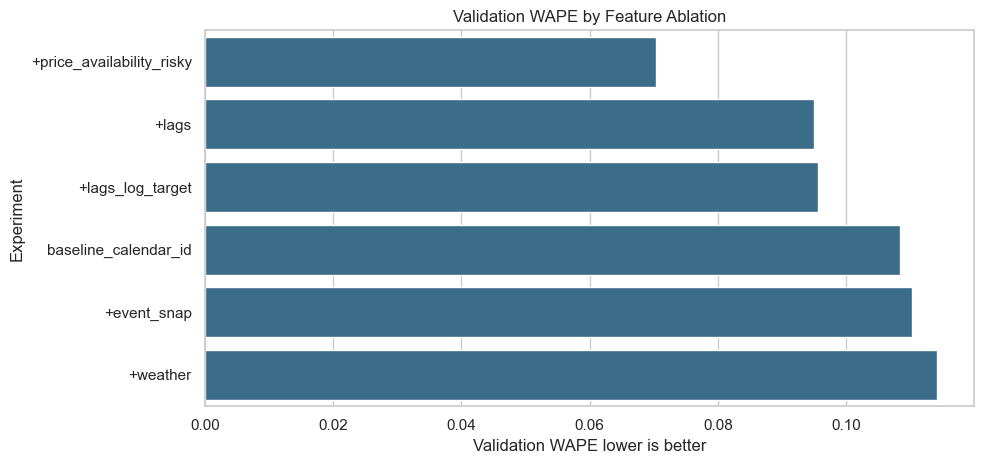

In [13]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cat_candidates = ['store_id', 'state_id', 'cat_id', 'dept_id', 'event_type_1', 'event_name_1']
for col in cat_candidates:
    if col in df_model.columns:
        categories = pd.Categorical(df_model[col].fillna('None')).categories
        for part in [train, val, test]:
            part[col] = pd.Categorical(part[col].fillna('None'), categories=categories)

base_features = [
    'store_id', 'state_id', 'cat_id', 'dept_id',
    'day_of_week_num', 'is_weekend', 'month', 'quarter', 'week_of_year',
    'day_of_month', 'day_of_year', 'year', 'days_since_start'
]
event_features = ['event_count', 'event_type_1', 'event_name_1', 'snap_active']
weather_features = [
    'weather_code', 'temperature_max_c', 'temperature_min_c', 'temperature_mean_c',
    'apparent_temperature_mean_c', 'precipitation_mm', 'rain_mm', 'snowfall_cm',
    'wind_speed_max_kmh', 'wind_gusts_max_kmh', 'shortwave_radiation_mj_m2',
    'rain_flag', 'heavy_rain_flag', 'temp_mean_sq'
]
lag_features = [c for c in df_model.columns if c.startswith('revenue_lag_') or c.startswith('revenue_roll_')]
price_availability_features = ['weighted_avg_sell_price', 'item_count', 'active_item_count']

def keep_existing(cols):
    return [c for c in cols if c in df_model.columns]

def metrics(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
        'WAPE': np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()
    }

experiments = [
    ('baseline_calendar_id', keep_existing(base_features), False),
    ('+event_snap', keep_existing(base_features + event_features), False),
    ('+weather', keep_existing(base_features + event_features + weather_features), False),
    ('+lags', keep_existing(base_features + event_features + weather_features + lag_features), False),
    ('+lags_log_target', keep_existing(base_features + event_features + weather_features + lag_features), True),
    ('+price_availability_risky', keep_existing(base_features + event_features + weather_features + lag_features + price_availability_features), False),
]

results = []
models = {}
predictions = {}

for name, features, use_log_target in experiments:
    model = LGBMRegressor(
        n_estimators=600,
        learning_rate=0.04,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=0.10,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    categorical_feature = [c for c in features if str(train[c].dtype) == 'category']
    y_train = np.log1p(train['daily_revenue']) if use_log_target else train['daily_revenue']
    model.fit(train[features], y_train, categorical_feature=categorical_feature)
    val_pred = model.predict(val[features])
    test_pred = model.predict(test[features])
    if use_log_target:
        val_pred = np.expm1(val_pred)
        test_pred = np.expm1(test_pred)

    val_metrics = metrics(val['daily_revenue'], val_pred)
    test_metrics = metrics(test['daily_revenue'], test_pred)
    row = {'experiment': name, 'n_features': len(features), 'log_target': use_log_target}
    row.update({f'val_{k}': v for k, v in val_metrics.items()})
    row.update({f'test_{k}': v for k, v in test_metrics.items()})
    results.append(row)
    models[name] = {'model': model, 'features': features, 'use_log_target': use_log_target}
    predictions[name] = {'val': np.clip(val_pred, 0, None), 'test': np.clip(test_pred, 0, None)}

results_df = pd.DataFrame(results)
metric_cols = ['val_MAE', 'val_RMSE', 'val_R2', 'val_WAPE', 'test_MAE', 'test_RMSE', 'test_R2', 'test_WAPE']
display(results_df[['experiment', 'n_features', 'log_target'] + metric_cols].round(4))

plt.figure(figsize=(10, 4.8))
plot_data = results_df.sort_values('val_WAPE')
sns.barplot(data=plot_data, x='val_WAPE', y='experiment', color='#2E6F95')
plt.title('Validation WAPE by Feature Ablation')
plt.xlabel('Validation WAPE lower is better')
plt.ylabel('Experiment')
plt.tight_layout()
plt.show()

**Đọc output thật:** Calendar/id baseline đã khá mạnh vì store/dept/time structure giải thích nhiều doanh thu. Event/SNAP và weather không cải thiện validation trong model global này; dù EDA có business signal, chúng có thể bị calendar/store/dept/lag hấp thụ hoặc không ổn định đủ để cải thiện forecast.

Lag/rolling past revenue là cải thiện rõ nhất trong nhóm feature sạch: validation WAPE giảm từ khoảng 10.84% xuống 9.50%, test WAPE khoảng 8.24%. Log-transform target không cải thiện so với raw target. Nhóm price/availability giảm validation WAPE xuống khoảng 7.03%, nhưng đây là mô hình rủi ro vì `active_item_count` và `weighted_avg_sell_price` có thể không thật sự biết trước hoặc có thể phụ thuộc sales mix thực tế.

**Kết luận model tạm thời:**
- **Operational clean model:** `+lags`, vì dùng feature hợp lệ hơn cho forecasting.
- **Risky upper-bound model:** `+price_availability_risky`, chỉ dùng nếu xác nhận được data lineage và availability tại thời điểm dự báo.

**Câu hỏi tiếp theo:** Model sạch đang dựa vào feature nào nhiều nhất, và sai nhiều ở đâu?

**Quyết định:** Phân tích feature importance và error analysis trên test cho model `+lags`.

## 12. Feature importance của clean operational model

**Câu hỏi đang kiểm tra:** Model `+lags` học từ calendar/store/dept/weather hay chủ yếu từ demand history?

**Vì sao quan trọng:** Feature importance giúp nối kết EDA với forecast behavior, nhưng phải đọc cùng ablation để tránh diễn giải quá mức.

,feature,importance
10,day_of_year,2424
9,day_of_month,2372
33,revenue_lag_28,2023
4,day_of_week_num,1858
31,revenue_lag_7,1762
35,revenue_roll_mean_7,1687
0,store_id,1570
36,revenue_roll_std_7,1547
27,shortwave_radiation_mj_m2,1318
12,days_since_start,1305


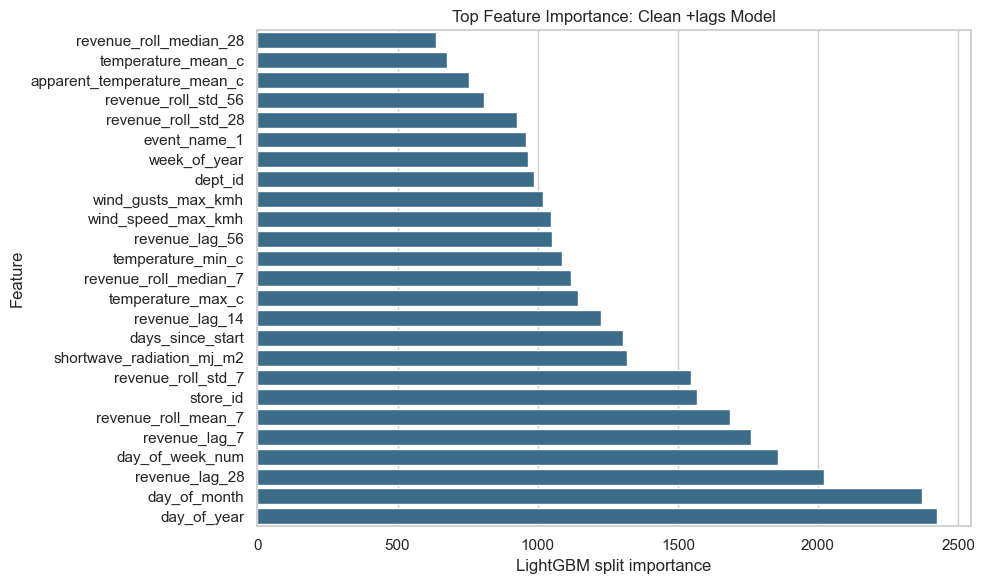

In [14]:
selected_model_name = '+lags'
selected = models[selected_model_name]
selected_model = selected['model']
selected_features = selected['features']

importance = (
    pd.DataFrame({'feature': selected_features, 'importance': selected_model.feature_importances_})
      .sort_values('importance', ascending=False)
      .head(25)
)
display(importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.sort_values('importance'), x='importance', y='feature', color='#2E6F95')
plt.title('Top Feature Importance: Clean +lags Model')
plt.xlabel('LightGBM split importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Đọc output thật:** Feature quan trọng nhất thuộc về lag/rolling và time/store/dept/calendar. Weather variables có thể xuất hiện trong importance, nhưng ablation cho thấy thêm weather trước khi có lag làm validation xấu hơn; vì vậy không nên kết luận weather là driver forecast mạnh chỉ từ importance.

**Insight:** Mô hình forecast tốt hơn chủ yếu nhờ demand persistence và level structure theo store/dept. EDA calendar/SNAP/event vẫn có giá trị business, nhưng trong model này chúng không phải nguồn cải thiện metric lớn nhất.

**Câu hỏi tiếp theo:** Model sai nhiều ở nhóm sản phẩm, revenue bucket, ngày trong tuần hay các spike cụ thể?

**Quyết định:** Chạy error analysis trên test cho model `+lags`.

## 13. Error analysis trên test set

**Câu hỏi đang kiểm tra:** Model sai nhiều ở đâu và có bias hệ thống không?

**Vì sao quan trọng:** Metric tổng thể có thể che giấu lỗi ở dept nhỏ, high-revenue spikes, hoặc ngày cụ thể. Error analysis giúp đề xuất bước cải thiện tiếp theo.

Error by department:


,rows,actual,pred,MAE,bias,WAPE
dept_id,,,,,,
HOBBIES_2,560,4.980909e+04,4.831126e+04,21.3040,-2.6747,0.2395
FOODS_1,560,5.180044e+05,5.077309e+05,114.2366,-18.3456,0.1235
HOUSEHOLD_2,560,5.678769e+05,5.533861e+05,102.2892,-25.8765,0.1009
HOBBIES_1,560,9.334931e+05,9.248223e+05,162.7452,-15.4836,0.0976
FOODS_2,560,1.152484e+06,1.144073e+06,181.5993,-15.0191,0.0882
HOUSEHOLD_1,560,1.731412e+06,1.721938e+06,243.2405,-16.9165,0.0787
FOODS_3,560,2.696077e+06,2.660517e+06,300.7120,-63.4991,0.0625



Error by revenue bucket:


,rows,avg_actual,MAE,bias,WAPE
revenue_bucket,,,,,
Q1 low,980,328.3416,45.7143,16.5851,0.1392
Q2,980,1083.5912,117.7653,-2.0467,0.1087
Q3,980,2006.9143,178.4634,-17.9185,0.0889
Q4 high,980,4386.4141,301.5580,-86.7999,0.0687



Error by day of week:


,rows,avg_actual,MAE,bias,WAPE
day_of_week,,,,,
Wednesday,560,1661.9379,144.0016,-11.2237,0.0866
Friday,560,1929.4946,167.0686,-6.0089,0.0866
Thursday,560,1680.7292,145.2279,-14.2625,0.0864
Tuesday,560,1736.6277,143.5354,-21.4487,0.0827
Saturday,560,2348.7909,187.6501,-11.4954,0.0799
Sunday,560,2442.7012,194.4005,-69.6657,0.0796
Monday,560,1858.9258,144.2426,-23.7103,0.0776



Worst individual test rows:


,date,store_id,state_id,cat_id,dept_id,daily_revenue,day_of_week,month,event_count,snap_active,temperature_mean_c,precipitation_mm,pred,error,abs_error,ape,revenue_bucket
114507,2016-05-11,WI_2,WI,FOODS,FOODS_3,7320.48,Wednesday,5,0,1,8.6,0.7,5488.29,-1832.19,1832.19,0.25,Q4 high
114511,2016-05-15,WI_2,WI,FOODS,FOODS_3,8944.60,Sunday,5,0,1,6.5,0.0,7163.81,-1780.79,1780.79,0.20,Q4 high
120290,2016-04-01,WI_2,WI,HOUSEHOLD,HOUSEHOLD_1,6042.60,Friday,4,0,0,4.2,1.6,4285.27,-1757.33,1757.33,0.29,Q4 high
114505,2016-05-09,WI_2,WI,FOODS,FOODS_3,7527.18,Monday,5,0,1,8.7,0.8,5919.93,-1607.25,1607.25,0.21,Q4 high
114510,2016-05-14,WI_2,WI,FOODS,FOODS_3,8051.40,Saturday,5,0,1,6.4,0.1,6648.79,-1402.61,1402.61,0.17,Q4 high
5815,2016-05-15,CA_1,CA,FOODS,FOODS_3,9015.73,Sunday,5,0,0,16.7,0.0,7627.53,-1388.20,1388.20,0.15,Q4 high
120318,2016-04-29,WI_2,WI,HOUSEHOLD,HOUSEHOLD_1,5093.66,Friday,4,0,0,4.8,0.7,3709.73,-1383.93,1383.93,0.27,Q4 high
5822,2016-05-22,CA_1,CA,FOODS,FOODS_3,8687.31,Sunday,5,0,0,16.7,0.0,7343.29,-1344.02,1344.02,0.15,Q4 high
112566,2016-05-11,WI_2,WI,FOODS,FOODS_2,5908.07,Wednesday,5,0,1,8.6,0.7,4590.08,-1317.99,1317.99,0.22,Q4 high
25225,2016-05-15,CA_2,CA,HOUSEHOLD,HOUSEHOLD_1,5812.11,Sunday,5,0,0,16.7,0.0,4571.06,-1241.05,1241.05,0.21,Q4 high


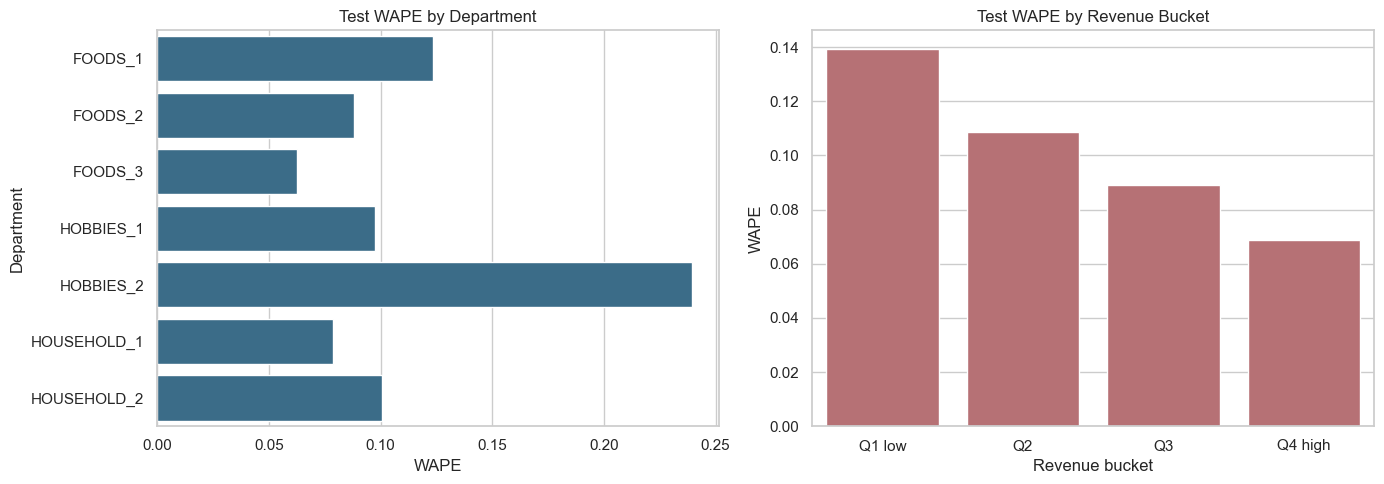

In [15]:
test_pred = predictions[selected_model_name]['test']
err = test[['date', 'store_id', 'state_id', 'cat_id', 'dept_id', 'daily_revenue', 'day_of_week', 'month', 'event_count', 'snap_active', 'temperature_mean_c', 'precipitation_mm']].copy()
err['pred'] = np.clip(test_pred, 0, None)
err['error'] = err['pred'] - err['daily_revenue']
err['abs_error'] = err['error'].abs()
err['ape'] = err['abs_error'] / err['daily_revenue'].replace(0, np.nan)
err['revenue_bucket'] = pd.qcut(err['daily_revenue'].rank(method='first'), 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])

def wape_for_group(x):
    return x.sum() / err.loc[x.index, 'daily_revenue'].sum()

error_by_dept = (
    err.groupby('dept_id')
       .agg(rows=('abs_error', 'size'), actual=('daily_revenue', 'sum'), pred=('pred', 'sum'), MAE=('abs_error', 'mean'), bias=('error', 'mean'), WAPE=('abs_error', wape_for_group))
       .sort_values('WAPE', ascending=False)
)
error_by_bucket = (
    err.groupby('revenue_bucket', observed=False)
       .agg(rows=('abs_error', 'size'), avg_actual=('daily_revenue', 'mean'), MAE=('abs_error', 'mean'), bias=('error', 'mean'), WAPE=('abs_error', wape_for_group))
)
error_by_dow = (
    err.groupby('day_of_week')
       .agg(rows=('abs_error', 'size'), avg_actual=('daily_revenue', 'mean'), MAE=('abs_error', 'mean'), bias=('error', 'mean'), WAPE=('abs_error', wape_for_group))
       .sort_values('WAPE', ascending=False)
)
worst_rows = err.sort_values('abs_error', ascending=False).head(10)

print('Error by department:')
display(error_by_dept.round(4))
print('\nError by revenue bucket:')
display(error_by_bucket.round(4))
print('\nError by day of week:')
display(error_by_dow.round(4))
print('\nWorst individual test rows:')
display(worst_rows.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=error_by_dept.reset_index().sort_values('WAPE'), x='WAPE', y='dept_id', ax=axes[0], color='#2E6F95')
axes[0].set_title('Test WAPE by Department')
axes[0].set_xlabel('WAPE')
axes[0].set_ylabel('Department')

sns.barplot(data=error_by_bucket.reset_index(), x='revenue_bucket', y='WAPE', ax=axes[1], color='#C1666B')
axes[1].set_title('Test WAPE by Revenue Bucket')
axes[1].set_xlabel('Revenue bucket')
axes[1].set_ylabel('WAPE')
plt.tight_layout()
plt.show()

**Đọc output thật:** Relative error cao nhất ở `HOBBIES_2`, dù absolute error nhỏ, vì doanh thu nền rất thấp. `FOODS_3` có absolute error lớn nhất tự nhiên vì volume cao, nhưng relative WAPE không phải tệ nhất. Theo bucket, nhóm doanh thu thấp có WAPE cao hơn, còn nhóm high-revenue có absolute error lớn hơn.

Bias trên test dương ở nhiều nhóm, nghĩa là model có xu hướng overpredict giai đoạn test. Worst rows chủ yếu là các spike/dip ở `FOODS_3` hoặc các store lớn; đây là nơi lag model khó bắt kịp khi demand thay đổi đột ngột.

**Insight mới từ error:** Nếu muốn cải thiện tiếp, cần feature về promotion/stockout/assortment planned ở cấp item hoặc cơ chế forecast recursive tốt hơn. Trong CSV hiện tại không có promotion trực tiếp; price/availability giúp metric nhưng chưa đủ an toàn về leakage.

**Quyết định:** Tổng hợp insight, feature decisions, ablation và hạn chế.

## 14. Tổng hợp cuối cùng

### Dataset, target và unit of analysis

- Dataset là daily retail panel ở mức **ngày × cửa hàng × department**.
- Target phù hợp: `daily_revenue`.
- Unit of analysis: `date-store_id-dept_id`.
- Bài toán phù hợp: descriptive retail analytics + time-aware regression/forecasting.
- Split đúng: theo thời gian, không random split.

### Các yếu tố ảnh hưởng đến doanh thu bán lẻ theo ngày

1. **Department và store structure là driver nền lớn nhất.** `FOODS_3` chiếm khoảng 37.8% doanh thu dù số dòng bằng các dept khác. `CA_3` là cửa hàng lớn nhất, chiếm khoảng 17.1% toàn dataset.
2. **Demand volume/assortment quan trọng hơn giá đơn vị.** `FOODS_3` có avg price không cao nhưng units và active items cao.
3. **Calendar effect rõ ràng.** Saturday/Sunday cao hơn store-dept median khoảng 23-26%; weekend lift khác nhau theo dept, mạnh nhất ở HOUSEHOLD.
4. **SNAP là signal cục bộ, không phải toàn dataset.** Lift mạnh nhất ở FOODS, đặc biệt WI/TX và `FOODS_2`/`FOODS_3`.
5. **Event có cả spike và shutdown.** Christmas gần như bằng 0, Thanksgiving thấp; SuperBowl/Easter/LaborDay cao hơn baseline.
6. **Weather có signal yếu/không ổn định.** Temperature pattern khác theo state, rain effect không rõ; ablation không ủng hộ weather là feature forecast mạnh trong dataset này.
7. **Past demand là feature dự báo mạnh nhất.** Lag/rolling revenue giúp validation WAPE giảm rõ rệt.

### Feature decisions

- **Giữ cho clean operational model:** store/state/category/dept IDs, calendar, lag/rolling revenue shifted, event/SNAP nếu cần interpretability.
- **Không dùng:** `daily_units`, `has_sales` vì leakage.
- **Cẩn trọng:** `weighted_avg_sell_price`, `active_item_count`; chỉ dùng nếu xác nhận biết trước và không được tính từ actual sales mix.
- **Weather:** giữ như exploratory hoặc scenario feature; không phải driver được ablation xác nhận trong model hiện tại.

### LightGBM result

- Clean operational model `+lags`: validation WAPE khoảng **9.50%**, test WAPE khoảng **8.24%**.
- Risky upper-bound `+price_availability_risky`: validation WAPE khoảng **7.03%**, test WAPE khoảng **7.75%**, nhưng không nên dùng làm kết luận operational nếu chưa xác nhận lineage.
- Log-transform target không cải thiện so với raw target.

### Error analysis

- Relative error cao nhất ở dept doanh thu nhỏ như `HOBBIES_2`.
- Absolute error lớn nhất thường nằm ở `FOODS_3` và store lớn vì đây là nhóm volume cao.
- Test bias có xu hướng overpredict, gợi ý demand level cuối giai đoạn test thấp hơn mô hình kỳ vọng từ lịch sử.
- Worst rows là các spike/dip lớn mà lag model khó bắt, có thể cần promotion/stockout/assortment/item-level feature ngoài CSV này.

### Biểu đồ nên đưa vào báo cáo

1. Distribution of `daily_revenue` và `log1p(daily_revenue)`.
2. Total revenue by `dept_id`.
3. Top store-dept combinations by total revenue.
4. Day-of-week normalized revenue ratio.
5. Weekend lift by `dept_id`.
6. SNAP lift heatmap by state and dept.
7. Temperature quintile effect by state.
8. Validation WAPE by ablation experiment.
9. Test WAPE by department and revenue bucket.

### Kết luận chính

Doanh thu bán lẻ theo ngày trong dataset này bị chi phối bởi **department/store baseline**, **demand persistence**, và **calendar/weekend behavior**. SNAP và event có ý nghĩa business nhưng tác động không đồng đều; weather có dấu hiệu nhưng không đủ ổn định để cải thiện forecast trong ablation. Với dữ liệu hiện có, mô hình LightGBM sạch nên ưu tiên lag/rolling shifted và calendar/store/dept identifiers; các feature price/availability chỉ nên dùng sau khi xác nhận không rò rỉ thông tin từ doanh số thực tế.